# 05. Gaussian Mixture Models (GMM) — Complete

This notebook develops **Gaussian Mixture Models (GMMs)** from intuition to mathematical formulation, implementation, model selection, diagnostics, and practical use.

We will use synthetic data so that the clustering behavior is visible and reproducible. The notebook emphasizes a key distinction: GMM is a **probabilistic model** that represents data as a mixture of Gaussian distributions, rather than assigning points only by distance to a centroid.

# 1. Problem & Motivation

Clustering is useful when observations do not come with known labels. But not all clusters are spherical or equally sized.

K-Means assigns each observation to its nearest centroid and works best when clusters are roughly compact and similarly scaled. A **Gaussian Mixture Model** instead models each cluster with a probability distribution.

Questions we will answer:
- What does a mixture of Gaussians mean?
- How does the Expectation-Maximization (EM) algorithm fit a GMM?
- How can we interpret probabilities, covariance shapes, and uncertainty?
- How do we choose the number of components?
- When is GMM useful, and when can it fail?

# 2. What Is a Gaussian Mixture Model?

A GMM assumes each observation was generated by one of several Gaussian components. Each component has:
- a mean vector \(\mu_k\), describing its center,
- a covariance matrix \(\Sigma_k\), describing its shape and orientation,
- a mixing coefficient \(\pi_k\), describing its prior proportion.

The density is

$$
p(x)=\sum_{k=1}^{K}\pi_k\,\mathcal{N}(x\mid\mu_k,\Sigma_k),
\qquad \pi_k\geq 0,\quad \sum_{k=1}^{K}\pi_k=1.
$$

Unlike hard clustering, GMM can report **soft membership probabilities**.

# 3. Intuition: Components Overlap

Imagine two clouds of measurements. Some points are clearly inside one cloud, while points in the overlap region plausibly belong to either one. GMM expresses this ambiguity as probabilities instead of pretending every assignment is certain.

A component is not necessarily a circular blob: its covariance can describe elongated, rotated ellipses.

# 4. The Gaussian Distribution

For a d-dimensional observation \(x\), a multivariate Gaussian is

$$
\mathcal{N}(x\mid\mu,\Sigma)=
\frac{1}{(2\pi)^{d/2}|\Sigma|^{1/2}}
\exp\left[-\frac12(x-\mu)^T\Sigma^{-1}(x-\mu)\right].
$$

The mean determines location. The covariance determines spread, correlation, and orientation. In two dimensions, covariance ellipses provide a useful visual summary.

# 5. Mixing Coefficients and Latent Membership

Let \(z_i\) be the unobserved component that generated observation \(x_i\). Before seeing the observation,

$$
P(z_i=k)=\pi_k.
$$

After observing \(x_i\), Bayes' rule gives the responsibility of component k:

$$
\gamma_{ik}=P(z_i=k\mid x_i)=
\frac{\pi_k\mathcal{N}(x_i\mid\mu_k,\Sigma_k)}
{\sum_{j=1}^{K}\pi_j\mathcal{N}(x_i\mid\mu_j,\Sigma_j)}.
$$

For each observation, responsibilities sum to one.

# 6. Maximum Likelihood and the EM Algorithm

GMM parameters are commonly estimated with **Expectation-Maximization (EM)**.

1. **Initialize** component parameters.
2. **E-step:** compute responsibilities $$ (\gamma_{ik}).$$
3. **M-step:** update mixing weights, means, and covariances using the responsibilities.
4. Repeat until the log-likelihood converges or a stopping condition is met.

EM alternates between estimating hidden memberships and updating the distributions. It typically finds a local optimum, not necessarily the global best solution.

# 7. The EM Updates

Define \(N_k=\sum_{i=1}^{N}\gamma_{ik}\). Then the updates are

$$
\pi_k=\frac{N_k}{N},\qquad
\mu_k=\frac{1}{N_k}\sum_i\gamma_{ik}x_i,
$$

$$
\Sigma_k=\frac{1}{N_k}\sum_i\gamma_{ik}(x_i-\mu_k)(x_i-\mu_k)^T.
$$

These are weighted estimates: points with larger responsibility for a component influence its parameters more strongly. Implementations use numerical safeguards because covariance matrices can become nearly singular.

# 8. A First Synthetic Example

We will generate two overlapping, elongated groups. This makes the limitations of distance-only intuition visible and gives us a controlled setting for inspecting estimated component distributions.

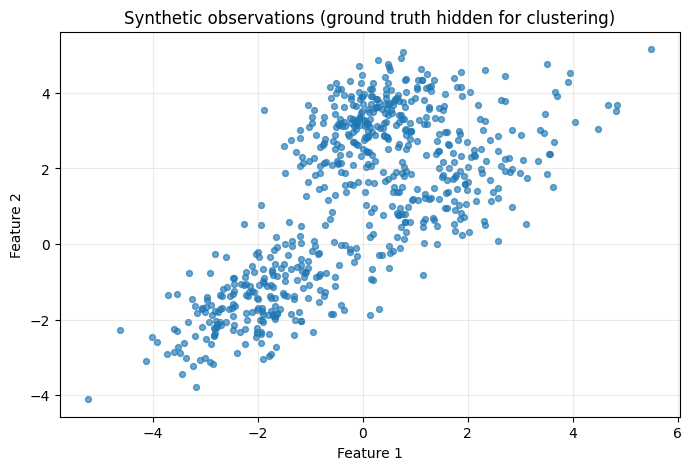

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, make_moons
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    adjusted_rand_score, silhouette_score,
    accuracy_score
)
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

X, y_true = make_blobs(
    n_samples=650,
    centers=[(-2.0, -0.5), (1.5, 1.2), (0.0, 4.0)],
    cluster_std=[1.0, 1.3, 0.75],
    random_state=RANDOM_STATE
)
# Stretch and rotate one direction to create more interesting covariance shapes.
transform = np.array([[1.0, 0.55], [0.0, 0.8]])
X = X @ transform

fig, ax = plt.subplots()
ax.scatter(X[:, 0], X[:, 1], s=18, alpha=0.65)
ax.set(title="Synthetic observations (ground truth hidden for clustering)", xlabel="Feature 1", ylabel="Feature 2")
plt.show()

# 9. Fit a Basic GMM

`n_components` is the number of Gaussian components, not a guarantee that the data contains exactly that many meaningful groups. `random_state` makes initialization reproducible; `n_init` tries multiple initializations and keeps the best fitted model.

In [2]:
gmm = GaussianMixture(
    n_components=3,
    covariance_type="full",
    n_init=5,
    reg_covar=1e-6,
    random_state=RANDOM_STATE
)
gmm.fit(X)

labels = gmm.predict(X)
responsibilities = gmm.predict_proba(X)

print("Converged:", gmm.converged_)
print("Iterations:", gmm.n_iter_)
print("Final log-likelihood per sample:", round(gmm.score(X), 4))
print("Mixing weights:", np.round(gmm.weights_, 3))
print("Means:\n", np.round(gmm.means_, 3))

Converged: True
Iterations: 4
Final log-likelihood per sample: -3.4859
Mixing weights: [0.335 0.383 0.282]
Means:
 [[-1.994 -1.439]
 [ 0.158  3.212]
 [ 1.654  1.591]]


# 10. Visualize Assignments and Component Means

The colors below show the most likely component. The marker `X` shows each fitted mean. Remember that the fitted labels are arbitrary identifiers: component 0 does not inherently correspond to ground-truth class 0.

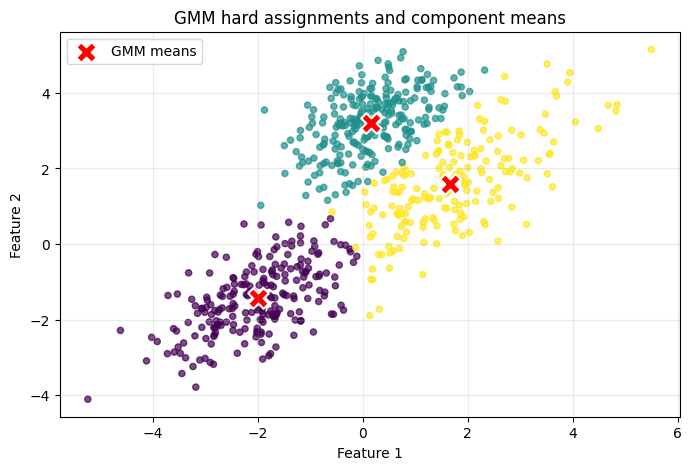

In [3]:
fig, ax = plt.subplots()
scatter = ax.scatter(X[:, 0], X[:, 1], c=labels, cmap="viridis", s=20, alpha=0.7)
ax.scatter(gmm.means_[:, 0], gmm.means_[:, 1], marker="X", s=220, c="red", edgecolor="white", linewidth=1.5, label="GMM means")
ax.set(title="GMM hard assignments and component means", xlabel="Feature 1", ylabel="Feature 2")
ax.legend()
plt.show()

# 11. Covariance Types

Scikit-learn supports four covariance parameterizations:

| Type | Meaning | Flexibility |
|---|---|---|
| `full` | Each component has its own general covariance matrix | Highest |
| `tied` | All components share one general covariance matrix | Medium |
| `diag` | Each component has its own diagonal covariance | Lower; no within-component feature correlations |
| `spherical` | Each component has one variance value | Lowest; spherical components |

More flexibility can fit richer shapes but requires more parameters and can overfit, especially with limited data.

# 12. Draw Covariance Ellipses

For two-dimensional data, eigenvectors of a covariance matrix give ellipse directions, and eigenvalues give squared axis scales. The following helper draws a contour-like ellipse for each fitted component.

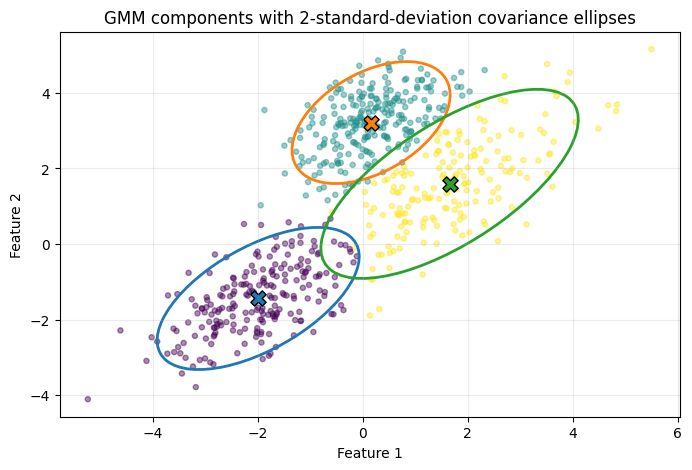

In [4]:
from matplotlib.patches import Ellipse

def draw_covariance_ellipse(ax, mean, covariance, color, n_std=2.0, **kwargs):
    # Eigen-decomposition gives principal directions and variances.
    values, vectors = np.linalg.eigh(covariance)
    order = values.argsort()[::-1]
    values, vectors = values[order], vectors[:, order]
    values = np.maximum(values, 0)
    angle = np.degrees(np.arctan2(vectors[1, 0], vectors[0, 0]))
    width, height = 2 * n_std * np.sqrt(values)
    ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle,
                      fill=False, edgecolor=color, linewidth=2, **kwargs)
    ax.add_patch(ellipse)
    return ellipse

fig, ax = plt.subplots()
ax.scatter(X[:, 0], X[:, 1], c=labels, cmap="viridis", s=14, alpha=0.45)
for k in range(gmm.n_components):
    draw_covariance_ellipse(ax, gmm.means_[k], gmm.covariances_[k], color=f"C{k}")
    ax.scatter(*gmm.means_[k], marker="X", s=120, color=f"C{k}", edgecolor="black")
ax.set(title="GMM components with 2-standard-deviation covariance ellipses", xlabel="Feature 1", ylabel="Feature 2")
plt.show()

# 13. Soft Clustering: Probabilities, Not Just Labels

`predict` returns the most likely component. `predict_proba` returns the full responsibility vector for every observation. A point might have probabilities `[0.51, 0.47, 0.02]`: its hard label is component 0, but the assignment is uncertain.

,component_0,component_1,component_2,predicted_component,max_probability
0,9.997251e-01,3.422348e-13,0.000275,0,0.999725
1,7.032977e-02,1.396010e-04,0.929531,2,0.929531
2,2.594519e-02,5.800652e-03,0.968254,2,0.968254
3,9.101020e-08,9.999045e-01,0.000095,1,0.999904
4,2.823676e-07,6.860334e-01,0.313966,1,0.686033
5,9.820157e-01,6.077244e-09,0.017984,0,0.982016
6,9.317339e-01,1.184346e-04,0.068148,0,0.931734
7,6.253662e-02,5.617116e-01,0.375752,1,0.561712
8,3.854723e-03,3.764191e-01,0.619726,2,0.619726
9,9.916942e-01,5.642859e-09,0.008306,0,0.991694


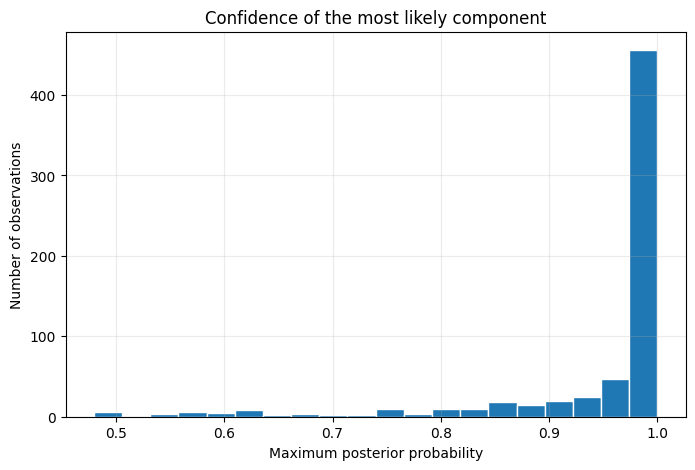

In [5]:
probability_table = pd.DataFrame(
    responsibilities,
    columns=[f"component_{k}" for k in range(gmm.n_components)]
)
probability_table["predicted_component"] = labels
probability_table["max_probability"] = responsibilities.max(axis=1)
display(probability_table.head(10))

fig, ax = plt.subplots()
ax.hist(probability_table["max_probability"], bins=20, edgecolor="white")
ax.set(title="Confidence of the most likely component", xlabel="Maximum posterior probability", ylabel="Number of observations")
plt.show()

# 14. Inspect Ambiguous Observations

Low maximum responsibility means that the model does not strongly favor one component. This can happen near overlapping groups, in sparse regions, or when the model is misspecified. It is not automatically an error or an outlier score.

In [6]:
ambiguous_idx = np.argsort(responsibilities.max(axis=1))[:10]
ambiguous = pd.DataFrame(X[ambiguous_idx], columns=["feature_1", "feature_2"])
ambiguous["predicted_component"] = labels[ambiguous_idx]
ambiguous["max_probability"] = responsibilities.max(axis=1)[ambiguous_idx]
display(ambiguous.sort_values("max_probability"))

,feature_1,feature_2,predicted_component,max_probability
0,-0.615805,0.671316,0,0.479638
1,-0.588380,0.847993,2,0.494149
2,-0.670227,1.156470,1,0.495051
3,0.133033,-1.888502,2,0.500189
4,1.451075,2.905525,2,0.500310
5,-0.113814,-0.322936,0,0.503896
6,0.750197,2.158215,1,0.527279
7,-0.134225,-0.094758,2,0.536474
8,-0.247786,-0.131680,0,0.544211
9,-0.234546,-0.205015,0,0.553891


# 15. Choosing the Number of Components: AIC and BIC

The number of components \(K\) is often unknown. Two common information criteria are:

$$
\mathrm{AIC}=2p-2\log\hat{L},\qquad
\mathrm{BIC}=p\log(N)-2\log\hat{L},
$$

where \(p\) is the number of estimated parameters, \(N\) is the number of observations, and $$(\hat{L})$$ is the maximized likelihood. **Lower is preferred** among models fit to the same data under comparable assumptions. BIC penalizes model complexity more strongly as sample size grows.

,n_components,AIC,BIC,log_likelihood_per_sample,converged
0,1,5048.22,5070.61,-3.88,True
1,2,4701.67,4750.92,-3.60,True
2,3,4565.62,4641.73,-3.49,True
3,4,4577.66,4680.63,-3.49,True
4,5,4579.91,4709.74,-3.48,True
5,6,4587.29,4743.99,-3.47,True
6,7,4595.98,4779.54,-3.47,True


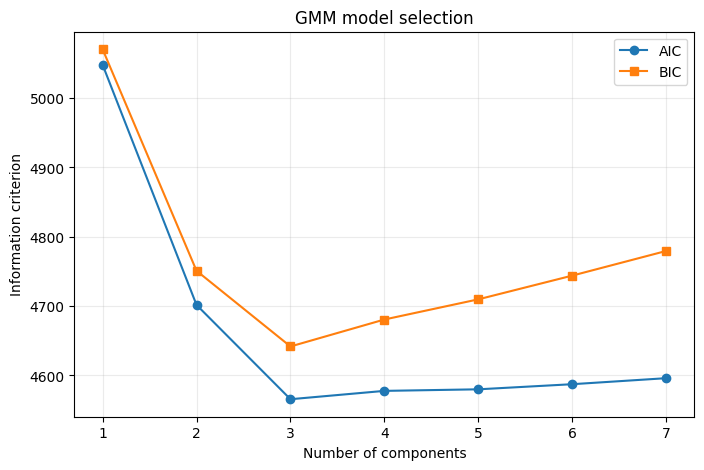

Best K by AIC: 3
Best K by BIC: 3


In [7]:
candidate_ks = range(1, 8)
selection_rows = []
candidate_models = {}

for k in candidate_ks:
    model = GaussianMixture(
        n_components=k, covariance_type="full",
        n_init=5, reg_covar=1e-6, random_state=RANDOM_STATE
    ).fit(X)
    candidate_models[k] = model
    selection_rows.append({
        "n_components": k,
        "AIC": model.aic(X),
        "BIC": model.bic(X),
        "log_likelihood_per_sample": model.score(X),
        "converged": model.converged_
    })

selection = pd.DataFrame(selection_rows)
display(selection.round(2))

fig, ax = plt.subplots()
ax.plot(selection["n_components"], selection["AIC"], marker="o", label="AIC")
ax.plot(selection["n_components"], selection["BIC"], marker="s", label="BIC")
ax.set(title="GMM model selection", xlabel="Number of components", ylabel="Information criterion")
ax.legend()
plt.show()

print("Best K by AIC:", int(selection.loc[selection["AIC"].idxmin(), "n_components"]))
print("Best K by BIC:", int(selection.loc[selection["BIC"].idxmin(), "n_components"]))

# 16. Important Caveat About AIC/BIC

AIC and BIC are useful guides, not ground-truth detectors of the number of semantic groups. Results depend on distributional assumptions, covariance type, sample size, and whether the model family is appropriate. A single real-world group may be approximated by several Gaussians if its shape is complex.

# 17. Compare Covariance Types

Keep the data and number of components fixed while changing the covariance assumption. This comparison helps show how flexibility affects fit and complexity.

In [8]:
covariance_rows = []
covariance_models = {}
for covariance_type in ["full", "tied", "diag", "spherical"]:
    model = GaussianMixture(
        n_components=3, covariance_type=covariance_type,
        n_init=5, reg_covar=1e-6, random_state=RANDOM_STATE
    ).fit(X)
    covariance_models[covariance_type] = model
    covariance_rows.append({
        "covariance_type": covariance_type,
        "AIC": model.aic(X),
        "BIC": model.bic(X),
        "converged": model.converged_,
        "iterations": model.n_iter_
    })
display(pd.DataFrame(covariance_rows).sort_values("BIC").round(2))

,covariance_type,AIC,BIC,converged,iterations
0,full,4565.62,4641.73,True,4
1,tied,4600.14,4649.38,True,3
3,spherical,4701.16,4750.40,True,12
2,diag,4704.98,4767.66,True,14


# 18. K-Means vs GMM

Both methods can produce cluster labels, but their assumptions differ.

| Property | K-Means | GMM |
|---|---|---|
| Main idea | Nearest centroid | Mixture probability density |
| Assignment | Hard | Soft probabilities available |
| Cluster shape | Voronoi regions around centroids | Gaussian ellipses depending on covariance |
| Number of groups | Must choose K | Must choose K or compare criteria |
| Uncertainty | Not directly modeled | Posterior membership probabilities |
| Main fitting objective | Within-cluster squared distances | Likelihood |

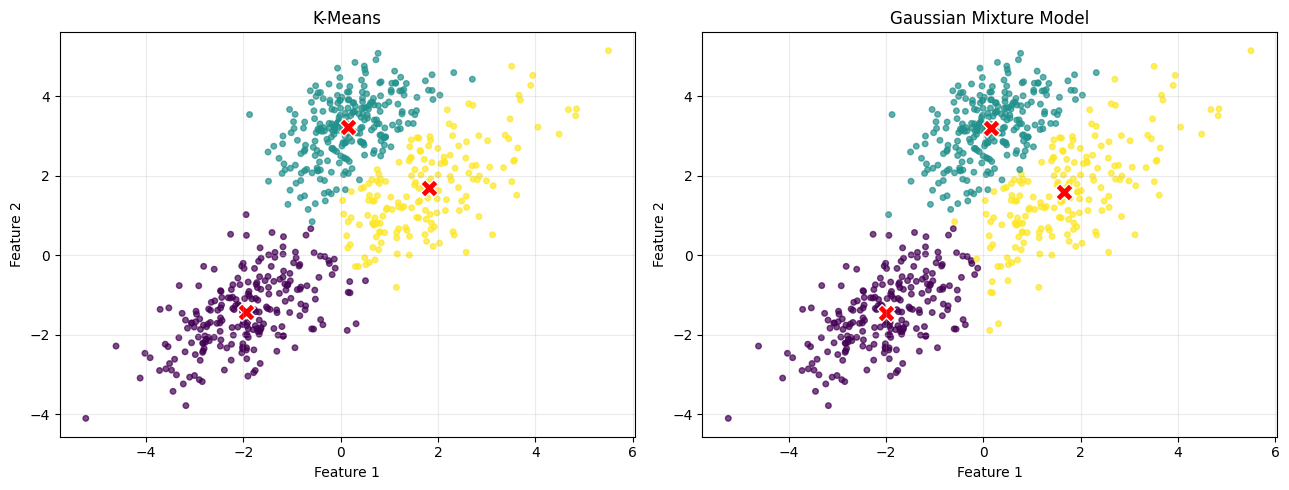

In [9]:
kmeans = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE).fit(X)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap="viridis", s=16, alpha=0.7)
axes[0].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker="X", s=160, c="red", edgecolor="white")
axes[0].set_title("K-Means")
axes[1].scatter(X[:, 0], X[:, 1], c=labels, cmap="viridis", s=16, alpha=0.7)
axes[1].scatter(gmm.means_[:, 0], gmm.means_[:, 1], marker="X", s=160, c="red", edgecolor="white")
axes[1].set_title("Gaussian Mixture Model")
for ax in axes:
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
plt.tight_layout()
plt.show()

# 19. Evaluation When Ground Truth Exists

In real unsupervised learning, ground-truth labels are often unavailable. When labels are available for a synthetic experiment or a benchmark, **Adjusted Rand Index (ARI)** compares partitions while accounting for chance. It does not require component IDs to match class IDs.

In [10]:
ari_gmm = adjusted_rand_score(y_true, labels)
ari_kmeans = adjusted_rand_score(y_true, kmeans.labels_)
print(f"GMM ARI:    {ari_gmm:.3f}")
print(f"K-Means ARI:{ari_kmeans:.3f}")

GMM ARI:    0.763
K-Means ARI:0.771


# 20. Silhouette Score: Use Carefully

Silhouette score measures separation under a chosen distance metric. It is more naturally aligned with distance-based compact clusters than with every possible probabilistic model. Use it as one diagnostic rather than the only criterion for choosing a GMM.

In [11]:
for name, predicted in [("GMM", labels), ("K-Means", kmeans.labels_)]:
    if len(np.unique(predicted)) > 1:
        print(f"{name} silhouette: {silhouette_score(X, predicted):.3f}")

GMM silhouette: 0.490
K-Means silhouette: 0.496


# 21. Feature Scaling

GMM estimates covariance, so feature units and scale affect the fitted distributions. If one feature is measured in thousands and another in fractions, the large-scale feature can dominate geometry and numerical behavior. Scaling is often appropriate, but it changes the geometry and therefore should reflect the domain meaning of the features.

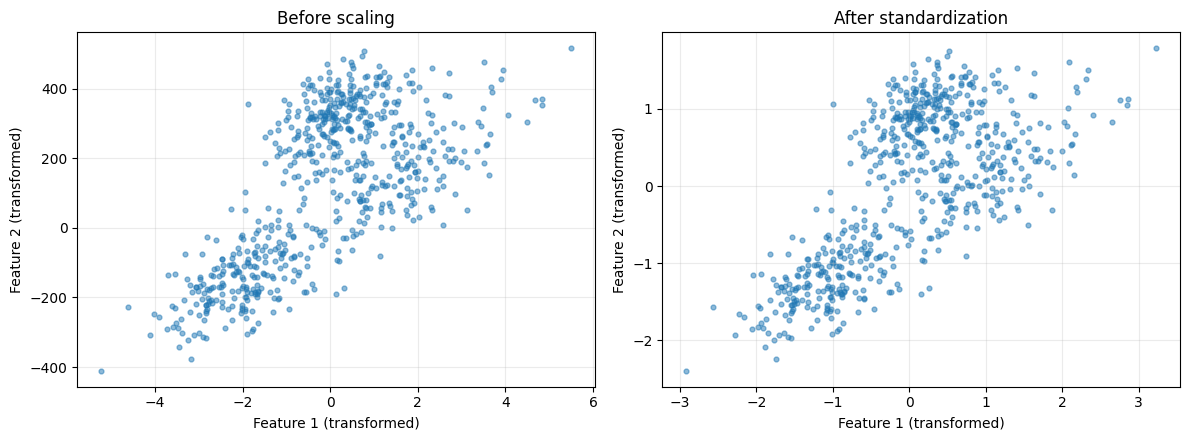

In [12]:
X_mixed_scale = X.copy()
X_mixed_scale[:, 1] *= 100
X_standardized = StandardScaler().fit_transform(X_mixed_scale)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(X_mixed_scale[:, 0], X_mixed_scale[:, 1], s=12, alpha=0.5)
axes[0].set_title("Before scaling")
axes[1].scatter(X_standardized[:, 0], X_standardized[:, 1], s=12, alpha=0.5)
axes[1].set_title("After standardization")
for ax in axes:
    ax.set_xlabel("Feature 1 (transformed)")
    ax.set_ylabel("Feature 2 (transformed)")
plt.tight_layout()
plt.show()

# 22. Initialization and Local Optima

EM depends on initialization. Different starting points can converge to different local optima. Practical safeguards include:
- multiple initializations with `n_init`,
- checking `converged_` and `n_iter_`,
- setting `random_state` for reproducibility,
- using reasonable scaling and inspecting tiny components,
- comparing results across seeds when conclusions matter.

In [13]:
init_rows = []
for seed in [0, 1, 7, 21, 42]:
    model = GaussianMixture(
        n_components=3, covariance_type="full",
        n_init=1, reg_covar=1e-6, random_state=seed
    ).fit(X)
    init_rows.append({
        "seed": seed,
        "lower_bound_per_sample": model.lower_bound_,
        "converged": model.converged_,
        "iterations": model.n_iter_,
        "smallest_weight": model.weights_.min()
    })
display(pd.DataFrame(init_rows).round(4))

,seed,lower_bound_per_sample,converged,iterations,smallest_weight
0,0,-3.4865,True,4,0.2802
1,1,-3.4865,True,4,0.2802
2,7,-3.4862,True,4,0.2823
3,21,-3.4865,True,4,0.2802
4,42,-3.4862,True,4,0.2823


# 23. Numerical Stability and Regularization

A covariance matrix that becomes nearly singular can cause unstable likelihood calculations. `reg_covar` adds a small non-negative value to covariance diagonals. This can improve numerical stability, but it is not a substitute for checking data quality or reconsidering an unsuitable model.

In [14]:
regularization_rows = []
for reg in [1e-8, 1e-6, 1e-4, 1e-2]:
    model = GaussianMixture(
        n_components=3, covariance_type="full",
        n_init=3, reg_covar=reg, random_state=RANDOM_STATE
    ).fit(X)
    regularization_rows.append({
        "reg_covar": reg,
        "converged": model.converged_,
        "lower_bound": model.lower_bound_,
        "minimum_weight": model.weights_.min()
    })
display(pd.DataFrame(regularization_rows).round(6))

,reg_covar,converged,lower_bound,minimum_weight
0,0.000000,True,-3.486246,0.282290
1,0.000001,True,-3.486246,0.282290
2,0.000100,True,-3.486247,0.282275
3,0.010000,True,-3.486789,0.278779


# 24. Outlier / Novelty Scoring with Log-Likelihood

`score_samples(X)` returns the log density under the fitted mixture. Very low values indicate observations that the model considers relatively unlikely. This is a **model-relative anomaly signal**, not a universal outlier definition; thresholds should be calibrated to the application and validation data.

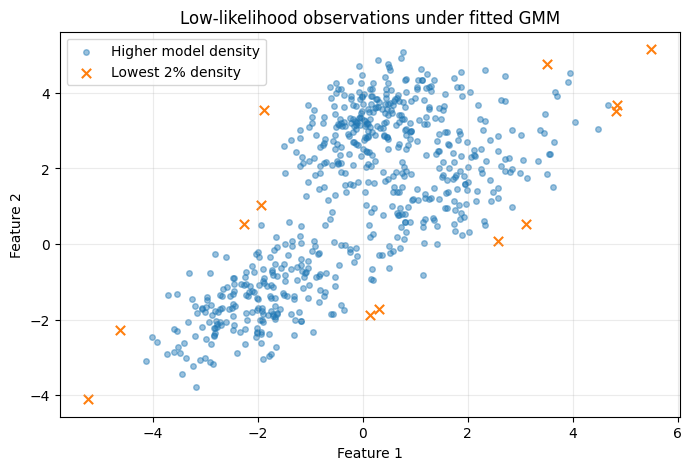

Low-density threshold: -6.261
Flagged observations: 13


In [15]:
sample_scores = gmm.score_samples(X)
threshold = np.quantile(sample_scores, 0.02)
low_density = sample_scores <= threshold

fig, ax = plt.subplots()
ax.scatter(X[~low_density, 0], X[~low_density, 1], s=16, alpha=0.45, label="Higher model density")
ax.scatter(X[low_density, 0], X[low_density, 1], s=45, marker="x", label="Lowest 2% density")
ax.set(title="Low-likelihood observations under fitted GMM", xlabel="Feature 1", ylabel="Feature 2")
ax.legend()
plt.show()
print("Low-density threshold:", round(float(threshold), 3))
print("Flagged observations:", int(low_density.sum()))

# 25. GMM and Non-Convex Clusters

A single Gaussian component has ellipsoidal level sets. A mixture can approximate more complicated densities by combining components, but that does not mean GMM will naturally discover arbitrary shapes with a small number of components. Let's compare it with the classic two-moons dataset.

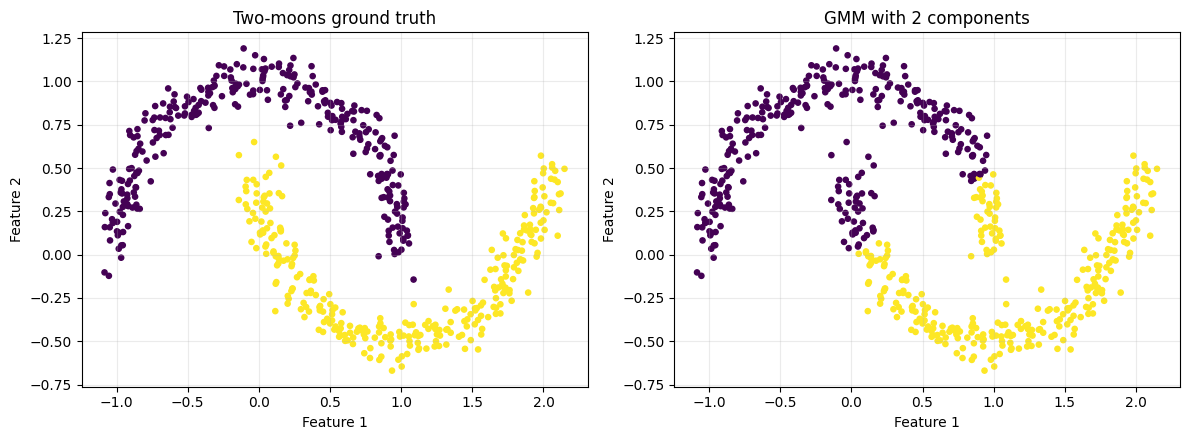

Two-moons GMM ARI: 0.494


In [16]:
X_moons, y_moons = make_moons(n_samples=600, noise=0.07, random_state=RANDOM_STATE)
moon_gmm = GaussianMixture(n_components=2, covariance_type="full", n_init=5, random_state=RANDOM_STATE).fit(X_moons)
moon_labels = moon_gmm.predict(X_moons)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap="viridis", s=14)
axes[0].set_title("Two-moons ground truth")
axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=moon_labels, cmap="viridis", s=14)
axes[1].set_title("GMM with 2 components")
for ax in axes:
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
plt.tight_layout()
plt.show()
print("Two-moons GMM ARI:", round(adjusted_rand_score(y_moons, moon_labels), 3))

# 26. GMM in Higher Dimensions

GMM covariance estimation becomes more demanding as feature count grows. A full covariance matrix for each component has many parameters, so high-dimensional settings may require more data, dimensionality reduction, diagonal/tied covariance assumptions, regularization, or domain-informed feature selection.

In [17]:
rng = np.random.default_rng(RANDOM_STATE)
X_high = rng.normal(size=(400, 20))
X_high[:, :3] += rng.normal(size=(400, 1)) * 1.5

high_rows = []
for covariance_type in ["full", "tied", "diag", "spherical"]:
    model = GaussianMixture(
        n_components=3, covariance_type=covariance_type,
        n_init=3, reg_covar=1e-5, random_state=RANDOM_STATE
    ).fit(X_high)
    high_rows.append({
        "covariance_type": covariance_type,
        "BIC": model.bic(X_high),
        "converged": model.converged_,
        "iterations": model.n_iter_
    })
display(pd.DataFrame(high_rows).sort_values("BIC").round(2))

,covariance_type,BIC,converged,iterations
3,spherical,24057.24,True,4
2,diag,24283.90,True,6
1,tied,24885.19,True,42
0,full,26881.62,True,26


# 27. A Practical Workflow

A defensible workflow is:

1. Define the clustering question and inspect data quality.
2. Choose meaningful features; handle missing values and scaling.
3. Fit a range of component counts and covariance types.
4. Use multiple initializations and check convergence.
5. Compare AIC/BIC and domain plausibility.
6. Inspect component weights, means, covariance shapes, and assignment uncertainty.
7. Validate stability and usefulness on held-out or downstream tasks where possible.
8. Document assumptions and limitations before interpreting clusters.

In [18]:
# Small reusable model-selection workflow.
def compare_gmm_models(X, component_counts=range(1, 8),
                       covariance_types=("full", "tied", "diag", "spherical"),
                       random_state=42):
    rows = []
    for covariance_type in covariance_types:
        for k in component_counts:
            model = GaussianMixture(
                n_components=k,
                covariance_type=covariance_type,
                n_init=5,
                reg_covar=1e-6,
                random_state=random_state
            ).fit(X)
            rows.append({
                "n_components": k,
                "covariance_type": covariance_type,
                "AIC": model.aic(X),
                "BIC": model.bic(X),
                "converged": model.converged_,
                "iterations": model.n_iter_
            })
    return pd.DataFrame(rows).sort_values("BIC").reset_index(drop=True)

workflow_results = compare_gmm_models(X, component_counts=range(1, 7))
display(workflow_results.head(12).round(2))

,n_components,covariance_type,AIC,BIC,converged,iterations
0,3,full,4565.62,4641.73,True,4
1,4,tied,4580.80,4643.48,True,6
2,3,tied,4600.14,4649.38,True,3
3,5,tied,4573.28,4649.39,True,7
4,6,tied,4573.52,4663.06,True,9
5,4,full,4577.66,4680.63,True,6
6,5,full,4579.91,4709.74,True,8
7,6,spherical,4615.63,4718.60,True,5
8,5,spherical,4644.52,4729.58,True,4
9,6,full,4587.29,4743.99,True,7


# 28. Interpreting Components Responsibly

A fitted component is a statistical description, not automatically a meaningful real-world category. For example, a component in customer data should not be labeled “high-value customers” solely because its mean spending is high. Validate interpretations with context, stability checks, and domain experts.

# 29. Common Failure Modes

- **Wrong number of components:** too few merges patterns; too many may split a meaningful group.
- **Poor initialization:** EM converges to a weak local optimum.
- **Singular covariance:** often related to too few points or redundant features.
- **Non-Gaussian geometry:** one component cannot represent rings or curved manifolds well.
- **Outliers:** extreme observations can distort means and covariance estimates.
- **Over-interpretation:** mathematical components are not necessarily natural classes.
- **Scale mismatch:** units can dominate covariance structure.

# 30. Computational Considerations

For N observations, K components, and d features, a full-covariance GMM involves covariance operations whose cost grows quickly with d. Memory and fitting time depend on sample size, feature dimension, number of components, covariance type, and initialization count. For large datasets, consider simpler covariance structures, dimensionality reduction, or alternative clustering methods.

# 31. Applications

GMMs can be useful for:
- customer or behavior segmentation with overlapping profiles,
- modeling heterogeneous populations,
- image segmentation and color modeling,
- anomaly or novelty scoring relative to a fitted density,
- speaker and signal modeling,
- exploratory scientific data analysis.

Use them when a Gaussian-mixture approximation is reasonable and probabilistic membership or density estimates are valuable.

# 32. Further Experiment: Change the Number of Components

Try changing `n_components` to 2, 3, 4, or 5 in the next cell. Compare the assignment plot, weights, ellipses, and BIC. Notice that extra components may improve likelihood while making interpretation more complicated.

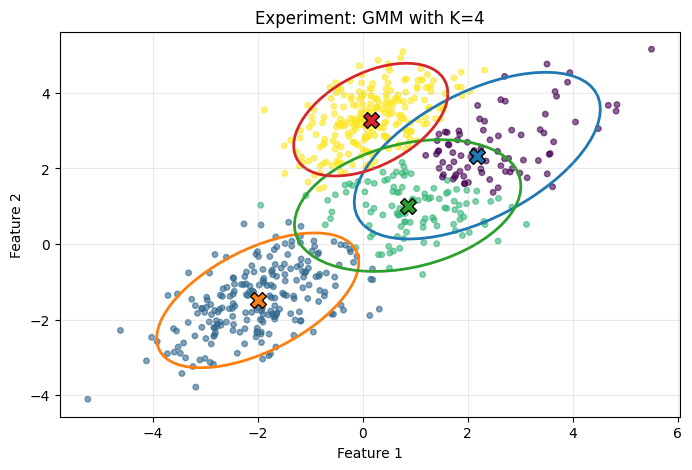

AIC: 4577.66
BIC: 4680.63
Weights: [0.151 0.331 0.163 0.356]


In [19]:
EXPERIMENT_K = 4  # Change this value and rerun the cell.
experiment_model = GaussianMixture(
    n_components=EXPERIMENT_K,
    covariance_type="full",
    n_init=5,
    reg_covar=1e-6,
    random_state=RANDOM_STATE
).fit(X)
experiment_labels = experiment_model.predict(X)

fig, ax = plt.subplots()
ax.scatter(X[:, 0], X[:, 1], c=experiment_labels, cmap="viridis", s=16, alpha=0.6)
for k in range(EXPERIMENT_K):
    draw_covariance_ellipse(ax, experiment_model.means_[k], experiment_model.covariances_[k], color=f"C{k}")
    ax.scatter(*experiment_model.means_[k], marker="X", s=130, color=f"C{k}", edgecolor="black")
ax.set(title=f"Experiment: GMM with K={EXPERIMENT_K}", xlabel="Feature 1", ylabel="Feature 2")
plt.show()
print("AIC:", round(experiment_model.aic(X), 2))
print("BIC:", round(experiment_model.bic(X), 2))
print("Weights:", np.round(experiment_model.weights_, 3))

# 33. Mini Exercises

1. Fit GMMs with `n_components=2`, `3`, and `4`. How do AIC and BIC change?
2. Compare `full` and `diag` covariance. Which gives the lower BIC for this dataset?
3. Find an observation with maximum responsibility below 0.60. Where is it located?
4. Change `n_init` from 1 to 10 and compare stability.
5. Run GMM on two-moons. Why does a two-component Gaussian mixture struggle to match curved clusters?
6. Explain why the component labels can change between runs without changing the meaning of the partition.

# 34. Key Takeaways

- **GMM is probabilistic:** each component is a Gaussian distribution.
- **EM fits the model:** E-step estimates responsibilities; M-step updates parameters.
- **Soft assignments matter:** posterior probabilities expose uncertainty.
- **Covariance type controls shape flexibility:** `full`, `tied`, `diag`, and `spherical`.
- **AIC/BIC help select complexity:** lower is preferred, but domain validation still matters.
- **Initialization and regularization matter:** inspect convergence and stability.
- **A component is not automatically a semantic class:** interpret results cautiously.

# 35. References

1. Dempster, A. P., Laird, N. M., & Rubin, D. B. (1977). *Maximum Likelihood from Incomplete Data via the EM Algorithm*. Journal of the Royal Statistical Society: Series B, 39(1), 1–38.
2. Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*. Springer. Chapter 9: Mixture Models and EM.
3. McLachlan, G., & Peel, D. (2000). *Finite Mixture Models*. Wiley.
4. Scikit-learn documentation: *GaussianMixture* — https://scikit-learn.org/stable/modules/mixture.html
5. Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Springer.